# Step 2: Tipping and hysteresis in Stommel's model

If I slowly make the flow harder to drive, does the temperature-driven circulation suddenly switch off, and does it come back when I undo the change? Here I sweep the flow resistance lambda up from 0.1 to 0.45 and back, and compare the path with all the equilibria.

I load the libraries and the shared Stommel functions from `src/models.py`. `%matplotlib inline` makes the figures show inside the notebook. The two `sys.path` lines let Python find `models.py`, which sits in the `src/` folder.

In [1]:
%matplotlib inline

import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

import sys
sys.path.append("../src")   # models.py lives in the project's src/ folder

from models import (stommel_flow, stommel_tendency, stommel_find_equilibria,
                    stommel_state_from_f, stommel_jacobian, classify_eigenvalues,
                    stommel_run_euler)

These are the parameter values: the lambda range, the time step, how long to settle at each lambda, and the grids for finding equilibria.

In [2]:
# ---------------- parameters ----------------
R = 2.0              # how strongly salinity affects density, relative to temperature
DELTA = 1.0 / 6.0    # salinity relaxes 6 times slower than temperature

LAM_START = 0.1      # lambda at the start and end of the sweep
LAM_END = 0.45       # largest lambda reached
N_SWEEP = 71         # lambda values in each direction (step 0.005)

DT = 0.01            # Euler time step; the states stay near equilibrium, so this is small enough (checked below)
T_SETTLE = 200.0     # time at each lambda; just past the fold the system lingers ~100 time units before jumping

F_MIN = -4.0         # f range searched for equilibria
F_MAX = 3.0
N_SCAN = 7001        # grid points in the f scan
N_LAM_GRID = 701     # lambda values for drawing the equilibrium branches

FIG_DIR = "../figures"
# --------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

This function steps through the lambda values. Each step starts from where the previous one ended, which is what lets the system remember its branch. That memory is the hysteresis. It also records how far from steady the state still is at the end of each step.

In [3]:
def sweep(lams, T0, S0, dt):
    """Step through lambda values, starting each one from the previous end state.

    Starting from the previous end state, not a fresh guess, is what a slowly
    changing climate does. It is also what lets the system remember which
    branch it is on, and that memory is the hysteresis.
    """
    f_end = np.zeros(len(lams))
    worst_residual = 0.0
    worst_lam = np.nan
    T = T0
    S = S0
    for k in range(len(lams)):
        T_path, S_path = stommel_run_euler(T, S, R, DELTA, lams[k], dt, T_SETTLE)
        T = T_path[-1]
        S = S_path[-1]
        f_end[k] = stommel_flow(T, S, R, lams[k])

        # How far from steady the state still is at the end of this lambda
        dTdt, dSdt = stommel_tendency(T, S, R, DELTA, lams[k])
        residual = max(abs(dTdt), abs(dSdt))
        if residual > worst_residual:
            worst_residual = residual
            worst_lam = lams[k]
    return f_end, T, S, worst_residual, worst_lam

This function asks whether a stable f < 0 equilibrium exists at a given lambda, using the step 1 root finder and the Jacobian. I use it for the bisection below.

In [4]:
def has_temperature_driven_state(lam):
    """True if a stable equilibrium with f < 0 exists at this lambda."""
    roots = stommel_find_equilibria(R, DELTA, lam, F_MIN, F_MAX, N_SCAN)
    for f in roots:
        if f < 0:
            T, S = stommel_state_from_f(f, DELTA)
            eigs = np.linalg.eigvals(stommel_jacobian(T, S, R, DELTA, lam))
            if classify_eigenvalues(eigs).startswith("stable"):
                return True
    return False

I find every equilibrium at 701 values of lambda and sort each one into a branch by its sign and stability. NaN gaps keep matplotlib from joining separate branches.

In [5]:
# ---- 1. All equilibria on a fine lambda grid (step 1 method) ----
# Each equilibrium goes into one of four branches by its sign of f and its
# stability. NaN leaves a gap, so matplotlib does not join separate branches.
lam_grid = np.linspace(LAM_START, LAM_END, N_LAM_GRID)
branch_names = ["f<0 stable", "f<0 unstable", "f>0 stable", "f>0 unstable"]
branches = {}
for name in branch_names:
    branches[name] = np.full(N_LAM_GRID, np.nan)

for j in range(N_LAM_GRID):
    lam = lam_grid[j]
    roots = stommel_find_equilibria(R, DELTA, lam, F_MIN, F_MAX, N_SCAN)
    for f in roots:
        T, S = stommel_state_from_f(f, DELTA)
        eigs = np.linalg.eigvals(stommel_jacobian(T, S, R, DELTA, lam))
        stable = classify_eigenvalues(eigs).startswith("stable")
        sign = "f<0" if f < 0 else "f>0"
        kind = "stable" if stable else "unstable"
        branches[sign + " " + kind][j] = f

I find the fold where the temperature-driven state disappears by bisection: I keep halving the interval between a lambda where the state exists and one where it does not.

In [6]:
# ---- 2. Where does the temperature-driven state disappear? ----
# Bisection: keep halving the interval between a lambda where the state
# exists and one where it does not.
lam_low = LAM_START
lam_high = LAM_END
if not has_temperature_driven_state(lam_low) or has_temperature_driven_state(lam_high):
    raise RuntimeError("bisection needs the f<0 state at LAM_START and not at LAM_END")
for it in range(40):
    lam_mid = 0.5 * (lam_low + lam_high)
    if has_temperature_driven_state(lam_mid):
        lam_low = lam_mid
    else:
        lam_high = lam_mid
lam_fold = 0.5 * (lam_low + lam_high)

As a check, I solve the equilibrium condition for lambda directly, lambda(f) = rhs(f)/f, and find its largest value. That maximum is the fold too, found in a completely different way.

In [7]:
# Independent check: for f < 0 the equilibrium condition can be solved for
# lambda directly, lambda(f) = rhs(f) / f. The fold is the largest lambda
# on this curve, because beyond it no f < 0 satisfies the condition.
def minus_lambda_of_f(f):
    rhs = -1.0 / (1.0 + abs(f)) + R * DELTA / (DELTA + abs(f))
    return -rhs / f

result = minimize_scalar(minus_lambda_of_f, bounds=(-3.0, -0.05), method="bounded",
                         options={"xatol": 1e-12})
lam_fold_check = -result.fun
f_at_fold = result.x

Stommel (1961, p. 229) read this fold off his hand-drawn graph as "slightly greater than 1/4". I check whether the temperature-driven state still exists just above 1/4. I also evaluate lambda(f) at f = -0.5, a quick hand estimate of the fold.

In [8]:
# Stommel's estimate from his graph: the fold is at lambda "slightly greater than 1/4".
# Count the f < 0 equilibria just above 1/4. Two of them (the node and the
# saddle) mean the temperature-driven state still exists there.
LAM_TESTS = [0.26, 0.30]
n_negative_roots = []
for lam_test in LAM_TESTS:
    roots = stommel_find_equilibria(R, DELTA, lam_test, F_MIN, F_MAX, N_SCAN)
    n_negative_roots.append(sum(1 for f in roots if f < 0))

# Hand estimate: at f = -0.5 the formula gives exactly 1/3, close to the maximum
lam_at_half = -minus_lambda_of_f(-0.5)


This is the sweep itself: up from 0.1 to 0.45, then back down, starting on the temperature-driven state. I repeat it with dt/2, and record the first lambda where the flow has switched sign.

In [9]:
# ---- 3. The slow sweep up and back down ----
# Start on the temperature-driven equilibrium at LAM_START.
roots_start = stommel_find_equilibria(R, DELTA, LAM_START, F_MIN, F_MAX, N_SCAN)
f_start = min(roots_start)          # the most negative root is the stable f<0 state
T0, S0 = stommel_state_from_f(f_start, DELTA)

lam_up = np.linspace(LAM_START, LAM_END, N_SWEEP)
lam_down = np.linspace(LAM_END, LAM_START, N_SWEEP)

f_up, T_top, S_top, res_up, lam_res_up = sweep(lam_up, T0, S0, DT)
f_down, T_end, S_end, res_down, lam_res_down = sweep(lam_down, T_top, S_top, DT)

# Same sweep with half the time step, to check the answer does not depend on dt
f_up_half, T_top_h, S_top_h, _, _ = sweep(lam_up, T0, S0, DT / 2)
f_down_half, _, _, _, _ = sweep(lam_down, T_top_h, S_top_h, DT / 2)
dt_diff = max(np.max(np.abs(f_up - f_up_half)), np.max(np.abs(f_down - f_down_half)))

# First lambda on the way up where the flow has switched to f > 0
k_jump = None
for k in range(N_SWEEP):
    if f_up[k] > 0:
        k_jump = k
        break
if k_jump is None:
    raise RuntimeError("the sweep up never switched to f > 0")
lam_jump_up = lam_up[k_jump]

This figure shows the sweep on top of the equilibrium branches (solid = stable, dashed = unstable), with an arrow at the tip.

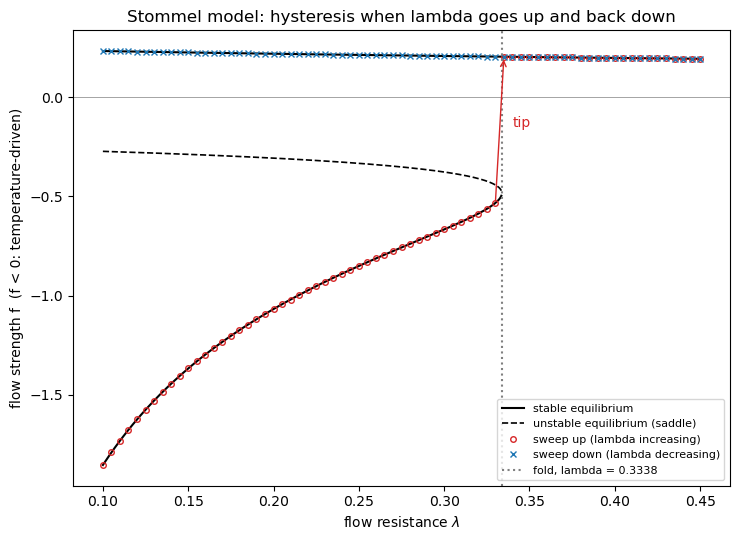

In [10]:
# ---- 4. Figure ----
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(lam_grid, branches["f<0 stable"], "k-", lw=1.5, label="stable equilibrium")
ax.plot(lam_grid, branches["f>0 stable"], "k-", lw=1.5)
ax.plot(lam_grid, branches["f<0 unstable"], "k--", lw=1.2, label="unstable equilibrium (saddle)")
ax.plot(lam_grid, branches["f>0 unstable"], "k--", lw=1.2)
ax.plot(lam_up, f_up, "o", color="tab:red", ms=4, mfc="none", label="sweep up (lambda increasing)")
ax.plot(lam_down, f_down, "x", color="tab:blue", ms=4, label="sweep down (lambda decreasing)")
ax.axvline(lam_fold, color="gray", ls=":", label=f"fold, lambda = {lam_fold:.4f}")
ax.axhline(0, color="gray", lw=0.5)
# Arrow for the tip: the jump from the last f<0 point to the first f>0 point
ax.annotate("", xy=(lam_up[k_jump], f_up[k_jump]), xytext=(lam_up[k_jump - 1], f_up[k_jump - 1]),
            arrowprops=dict(arrowstyle="->", color="tab:red"))
ax.text(lam_up[k_jump] + 0.005, -0.15, "tip", color="tab:red")
ax.set_xlabel(r"flow resistance $\lambda$")
ax.set_ylabel("flow strength f  (f < 0: temperature-driven)")
ax.set_title("Stommel model: hysteresis when lambda goes up and back down")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_stommel_hysteresis.png"), dpi=150)
plt.show()

Finally I print the fold location from both methods, the jump, the state at the end of the sweep down, and the settling and time step checks.

In [11]:
# ---- 5. Print the key numbers ----
print("Fold of the temperature-driven (f < 0) state")
print(f"  bisection with the step-1 root finder:  lambda = {lam_fold:.6f}")
print(f"  maximum of lambda(f) = rhs(f)/f:        lambda = {lam_fold_check:.6f}  (at f = {f_at_fold:.4f})")
print(f"  lambda(f) at f = -0.5 (hand estimate):  lambda = {lam_at_half:.6f}  (exactly 1/3)")
print("  Stommel (1961, p. 229), read off his graph: 'slightly greater than 1/4'")
for lam_test, n_neg in zip(LAM_TESTS, n_negative_roots):
    print(f"    at lambda = {lam_test:.2f} there are still {n_neg} equilibria with f < 0 (node and saddle)")
print()
print(f"Sweep up:   first lambda with f > 0 = {lam_jump_up:.3f}")
print(f"            f just before = {f_up[k_jump - 1]:+.4f} (lambda = {lam_up[k_jump - 1]:.3f}), "
      f"f just after = {f_up[k_jump]:+.4f}")
print(f"Sweep down: f at lambda = {lam_down[-1]:.2f} is {f_down[-1]:+.4f}  "
      f"(started the sweep up at f = {f_up[0]:+.4f})")
if np.min(f_down) > 0:
    verdict = "f stayed > 0: no return to the temperature-driven state"
else:
    verdict = "f went below 0: the system DID return to the temperature-driven state"
print(f"            smallest f on the way down = {np.min(f_down):+.4f}  ({verdict})")
print()
print("Equilibria at lambda = 0.1 (after the sweep the system sits on the f > 0 one):")
for f in roots_start:
    print(f"  f = {f:+.4f}")
print()
print(f"Largest |dT/dt| or |dS/dt| at the end of a lambda step: up {res_up:.2e} (at lambda = {lam_res_up:.3f}), "
      f"down {res_down:.2e} (at lambda = {lam_res_down:.3f})")
print(f"dt check: largest difference in recorded f between dt = {DT} and dt = {DT / 2}: {dt_diff:.2e}")

Fold of the temperature-driven (f < 0) state
  bisection with the step-1 root finder:  lambda = 0.333800
  maximum of lambda(f) = rhs(f)/f:        lambda = 0.333801  (at f = -0.4837)
  lambda(f) at f = -0.5 (hand estimate):  lambda = 0.333333  (exactly 1/3)
  Stommel (1961, p. 229), read off his graph: 'slightly greater than 1/4'
    at lambda = 0.26 there are still 2 equilibria with f < 0 (node and saddle)
    at lambda = 0.30 there are still 2 equilibria with f < 0 (node and saddle)

Sweep up:   first lambda with f > 0 = 0.335
            f just before = -0.5331 (lambda = 0.330), f just after = +0.2042
Sweep down: f at lambda = 0.10 is +0.2328  (started the sweep up at f = -1.8542)
            smallest f on the way down = +0.1937  (f stayed > 0: no return to the temperature-driven state)

Equilibria at lambda = 0.1 (after the sweep the system sits on the f > 0 one):
  f = -1.8542
  f = -0.2729
  f = +0.2328

Largest |dT/dt| or |dS/dt| at the end of a lambda step: up 9.97e-12 (at lamb